# Notebook 03 — Random Forest

## Théorie : Random Forest

### Principe : Ensemble Learning & Bagging
Le Random Forest est une méthode d'**ensemble learning** basée sur le **bagging** (Bootstrap Aggregating) :
- On crée $B$ sous-ensembles d'entraînement par **échantillonnage avec remise** (bootstrap)
- On entraîne un **arbre de décision** indépendant sur chaque sous-ensemble
- La prédiction finale est la **moyenne** des prédictions de tous les arbres (régression)

$$\hat{y}_{RF} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

### Aléatoire = Diversité
À chaque nœud, seul un sous-ensemble aléatoire de $\sqrt{p}$ features est considéré pour la division  
→ Réduit la corrélation entre les arbres → Réduit la variance globale

### Arbres de décision
Chaque arbre divise récursivement les données en cherchant la **feature** et le **seuil** qui minimisent l'impureté (MSE pour la régression).

### Importance des features
L'importance d'une feature est mesurée par la **réduction totale de l'impureté** qu'elle génère à travers tous les arbres (Mean Decrease Impurity – MDI) :
$$\text{Importance}(f) = \frac{1}{B} \sum_{b=1}^{B} \sum_{\text{noeuds avec } f} \Delta \text{MSE}$$

### Avantages vs Régression Linéaire
- Capture les relations **non-linéaires** et les **interactions** entre features
- Robuste aux **outliers** et aux valeurs aberrantes
- Pas besoin de normalisation
- Fournit une estimation de l'importance des features
- Moins sensible au surajustement qu'un arbre simple


In [1]:
# Imports et chargement des données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

with open('data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')

X_train : (4700, 17) | X_test : (705, 17)


In [2]:
# Recherche des meilleurs hyperparamètres par GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 10, 20]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

start = time.time()
grid_search.fit(X_train, y_train)
train_time = time.time() - start

print(f'\nGridSearchCV terminé en {train_time:.1f} secondes')
print(f'Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur score MSE (négatif) : {grid_search.best_score_:.0f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits

GridSearchCV terminé en 6.3 secondes
Meilleurs hyperparamètres : {'max_depth': 20, 'n_estimators': 100}
Meilleur score MSE (négatif) : -18608961768


In [3]:
# Modèle avec les meilleurs hyperparamètres
rf_model = grid_search.best_estimator_

# Affichage du résumé du meilleur modèle
print('Paramètres du meilleur modèle :')
for k, v in grid_search.best_params_.items():
    print(f'  {k:15s} : {v}')

Paramètres du meilleur modèle :
  max_depth       : 20
  n_estimators    : 100


In [4]:
# Prédictions et métriques
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('MÉTRIQUES — Random Forest')
print('=' * 40)
print(f'MAE   : {mae:,.0f} ha')
print(f'RMSE  : {rmse:,.0f} ha')
print(f'R²    : {r2:.4f}')
print(f'Temps : {train_time:.1f} s')
print('=' * 40)

results_rf = {'model': 'Random Forest', 'MAE': mae, 'RMSE': rmse, 'R2': r2,
              'train_time': train_time, 'y_pred': y_pred, 'y_test': y_test}
with open('models/results_rf.pkl', 'wb') as f:
    pickle.dump(results_rf, f)
print('Résultats sauvegardés dans models/results_rf.pkl')

MÉTRIQUES — Random Forest
MAE   : 26,824 ha
RMSE  : 215,519 ha
R²    : 0.8382
Temps : 6.3 s
Résultats sauvegardés dans models/results_rf.pkl


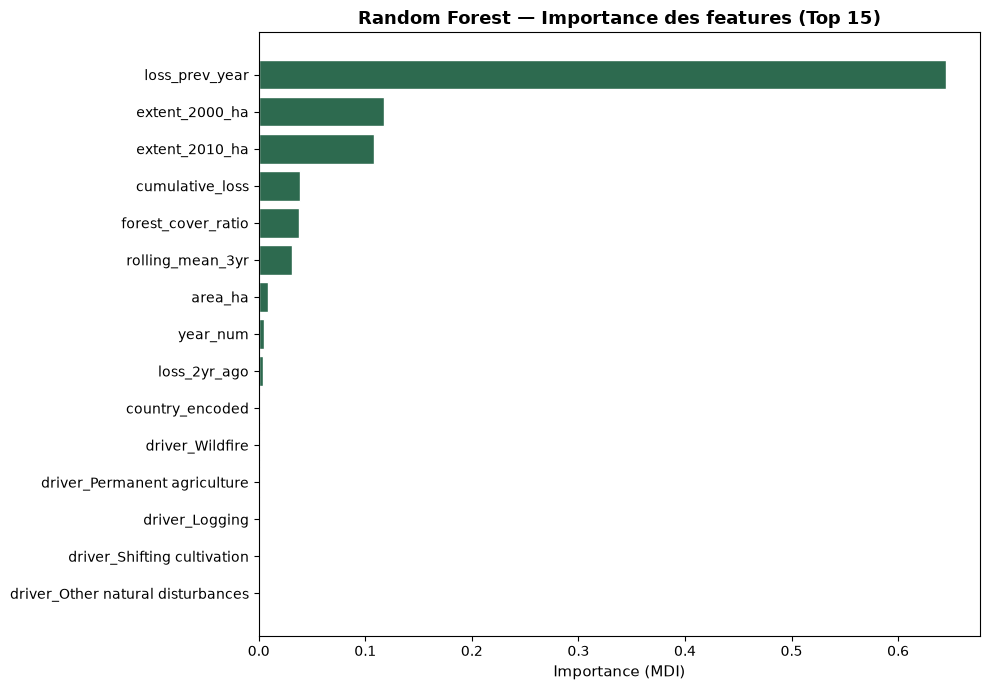

Figure sauvegardée


In [5]:
# Graphique d'importance des features (Top 15)
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance').tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_df['feature'], feat_df['importance'], color='#2d6a4f', edgecolor='white')
ax.set_title('Random Forest — Importance des features (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (MDI)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

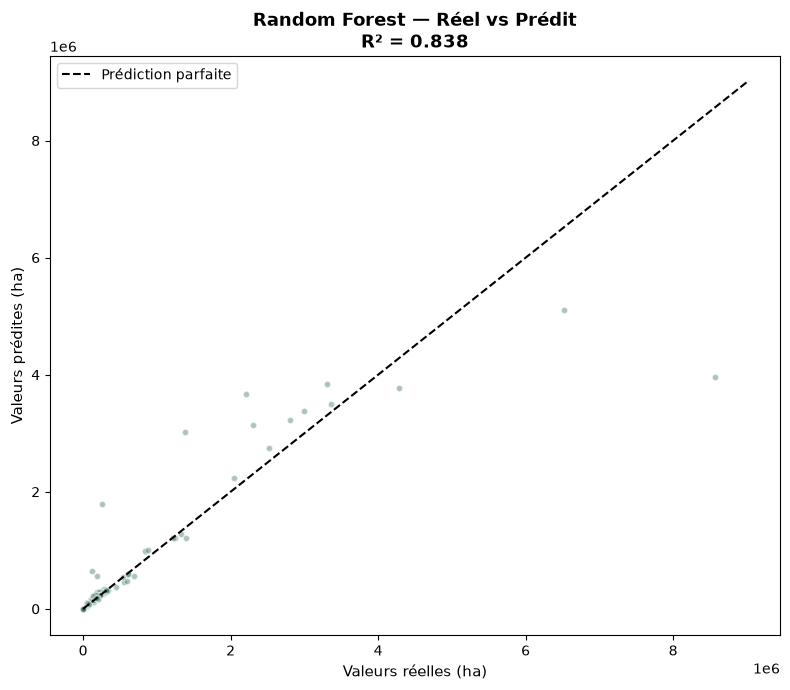

In [6]:
# Scatter plot : réel vs prédit
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=0.4, color='#2d6a4f', edgecolors='white', s=20)
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeurs réelles (ha)', fontsize=11)
ax.set_ylabel('Valeurs prédites (ha)', fontsize=11)
ax.set_title(f'Random Forest — Réel vs Prédit\nR² = {r2:.3f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/rf_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

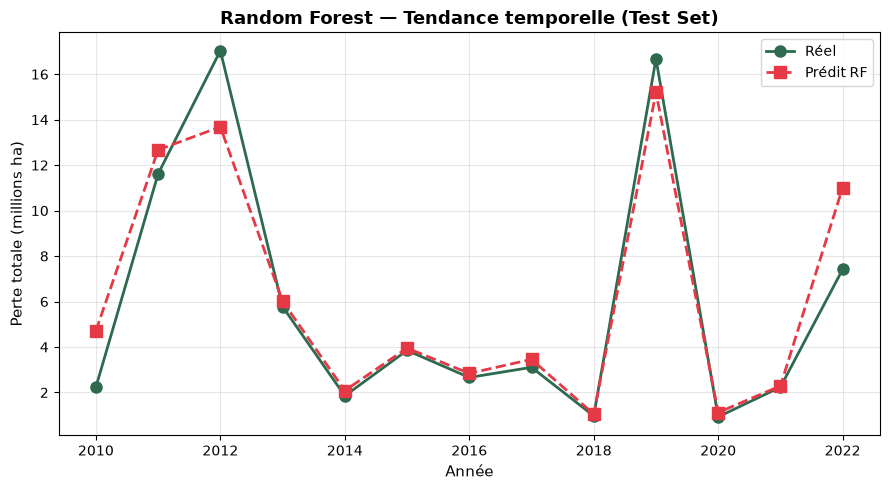

Toutes les figures sauvegardées dans figures/


In [7]:
# Courbe temporelle agrégée sur le test set
n_years_test = 13
n_per_year   = len(y_test) // n_years_test
years_test   = [2010 + i for i in range(n_years_test)]
real_sum     = [y_test[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]
pred_sum     = [y_pred[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(years_test, np.array(real_sum)/1e6, 'o-', color='#2d6a4f', linewidth=2, markersize=8, label='Réel')
ax.plot(years_test, np.array(pred_sum)/1e6, 's--', color='#e63946', linewidth=2, markersize=8, label='Prédit RF')
ax.set_title('Random Forest — Tendance temporelle (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Perte totale (millions ha)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/rf_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Toutes les figures sauvegardées dans figures/')